# **Smart Inhalo — Hybrid ML + DL Breathing Technique Classification**


**Goal:** classify a breathing cycle as `Correct` or `Wrong` technique, using real respiratory
measurements (derived from PhysioNet respiratory data), with a classical ML branch and a
deep learning branch.

**Data:** `Smart_Inhalo_Master_Dataset.csv` — 13,137 real breathing cycles from 79 subjects,
cycle-level features (flow, pressure, tidal volume, chest/abdomen movement) extracted from
real respiratory recordings.

**Workflow:**
1. Load the data
2. Split into train/test by subject
3. Build the `Correct` / `Wrong` technique label
4. Select model features (kept separate from the label-building columns)
5. Scale the features
6. Train classical ML models (Logistic Regression, Random Forest, SVM)
7. Train a deep learning model (MLP)
8. Compare all models (metrics, ROC/PR curves, confusion matrix)
9. Save the best model for deployment


##Import Libraries

In [4]:
#Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

RANDOM_STATE = 42
pd.set_option("display.width", 100)
sns.set_style("whitegrid")
plt.rcParams["figure.facecolor"] = "white"


## 1. Load the data

In [5]:
DATA_PATH = "Smart_Inhalo_Master_Dataset.csv"  # change this if your CSV is somewhere else

df = pd.read_csv('/content/Smart_Inhalo_Master_Dataset.csv')
print("Shape:", df.shape)
print("Subjects:", df["Subject_ID"].nunique())
df.head()


Shape: (13137, 26)
Subjects: 79


,Subject_ID,Cycle,Cycle_Duration_s,Peak_Flow_L_s,Min_Flow_L_s,Mean_Flow_L_s,Flow_Range_L_s,Flow_Std_L_s,Peak_Pressure_cmH2O,Min_Pressure_cmH2O,...,Abd_Range_mm,Trial Classification,Cycle_Duration_s_Abnormal,Flow_Range_L_s_Abnormal,Pressure_Range_cmH2O_Abnormal,Max_Tidal_Volume_L_Abnormal,Chest_Range_mm_Abnormal,Abd_Range_mm_Abnormal,Abnormal_Features,Technique_Label
0,1,1,5.21,0.739471,-0.522593,0.092576,1.262064,0.427873,2.617630,-3.282765,...,6.828055,Normal Female,0,1,0,1,1,1,4,Wrong
1,1,2,4.25,0.780341,-0.485627,0.131322,1.265969,0.417696,2.724910,-3.540237,...,6.696747,Normal Female,0,1,1,1,0,1,4,Wrong
2,1,3,4.11,0.780341,-0.522593,0.081677,1.302934,0.446625,2.445982,-3.636789,...,6.631092,Normal Female,0,1,0,1,0,1,3,Wrong
3,1,4,3.82,0.764256,-0.545847,0.075894,1.310103,0.459672,2.671270,-3.540237,...,6.893710,Normal Female,0,1,1,1,1,1,5,Wrong
4,1,5,4.23,0.764256,-0.485627,0.122607,1.249883,0.438376,2.370886,-3.400773,...,6.565438,Normal Female,0,1,0,1,0,1,3,Wrong


## 2. Subject-wise train/test split

Splitting by `Subject_ID` (not by row) means no subject's breathing cycles appear in both
train and test — otherwise the model could partly "recognize" a subject rather than learn
general breathing patterns.

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, groups=df["Subject_ID"]))

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print(f"Train: {len(train_df)} cycles from {train_df['Subject_ID'].nunique()} subjects")
print(f"Test:  {len(test_df)} cycles from {test_df['Subject_ID'].nunique()} subjects")
overlap = set(train_df["Subject_ID"]) & set(test_df["Subject_ID"])
print("Subject overlap between train and test:", len(overlap), "(should be 0)")


Train: 10051 cycles from 63 subjects
Test:  3086 cycles from 16 subjects
Subject overlap between train and test: 0 (should be 0)


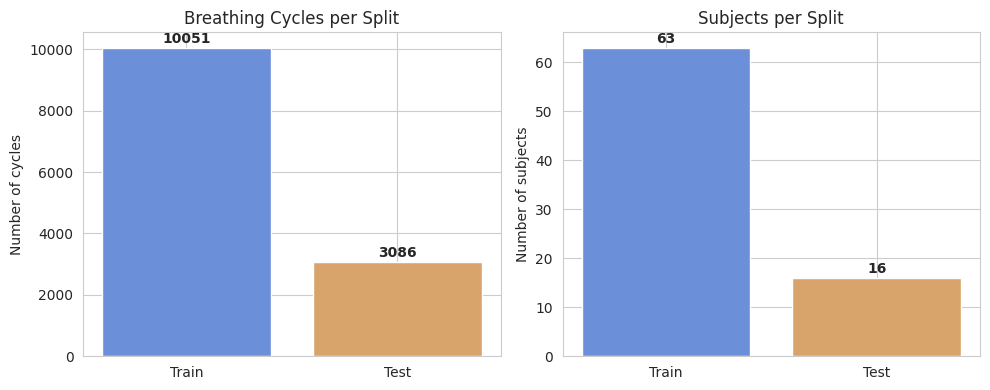

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["Train", "Test"], [len(train_df), len(test_df)], color=["#6C8FD9", "#D9A46C"])
axes[0].set_title("Breathing Cycles per Split")
axes[0].set_ylabel("Number of cycles")
for i, v in enumerate([len(train_df), len(test_df)]):
    axes[0].text(i, v + 150, str(v), ha="center", fontweight="bold")

axes[1].bar(
    ["Train", "Test"],
    [train_df["Subject_ID"].nunique(), test_df["Subject_ID"].nunique()],
    color=["#6C8FD9", "#D9A46C"],
)
axes[1].set_title("Subjects per Split")
axes[1].set_ylabel("Number of subjects")
for i, v in enumerate([train_df["Subject_ID"].nunique(), test_df["Subject_ID"].nunique()]):
    axes[1].text(i, v + 1, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("chart_split.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Build the technique label (leak-safe)

We flag a feature as "abnormal" for a cycle if it falls **below the 10th percentile or above
the 90th percentile** of that feature's distribution **in the training subjects only**. A
cycle is labeled `Wrong` if at least 3 of the 6 technique-related features are abnormal at
once, otherwise `Correct`.

Why 10th/90th percentile with a "3 out of 6" rule, and not something looser: using the
*interquartile range* (25th–75th percentile) as "normal" flags roughly half of all values as
abnormal for any single feature, almost by definition — so requiring only 2 of 6 to be
abnormal ends up labeling the large majority of the dataset "Wrong", which isn't a meaningful
signal. The 10th/90th + "3 of 6" combination was chosen by checking the resulting class
balance and picking a rule that actually behaves like an outlier detector rather than a
near-coin-flip.

In [8]:
label_features = [
    "Cycle_Duration_s", "Flow_Range_L_s", "Pressure_Range_cmH2O",
    "Max_Tidal_Volume_L", "Chest_Range_mm", "Abd_Range_mm",
]

# Bounds computed from TRAIN ONLY - test set never influences the label definition.
bounds = {f: (train_df[f].quantile(0.10), train_df[f].quantile(0.90)) for f in label_features}

def label_technique(data, bounds, min_abnormal=3):
    abnormal_count = pd.Series(0, index=data.index)
    for f in label_features:
        lo, hi = bounds[f]
        abnormal_count += ((data[f] < lo) | (data[f] > hi)).astype(int)
    return np.where(abnormal_count >= min_abnormal, "Wrong", "Correct"), abnormal_count

train_df["Technique"], train_df["Abnormal_Count"] = label_technique(train_df, bounds)
test_df["Technique"], test_df["Abnormal_Count"] = label_technique(test_df, bounds)

print("Train label balance:")
print(train_df["Technique"].value_counts(normalize=True).round(3))
print()
print("Test label balance:")
print(test_df["Technique"].value_counts(normalize=True).round(3))


Train label balance:
Technique
Correct    0.85
Wrong      0.15
Name: proportion, dtype: float64

Test label balance:
Technique
Correct    0.871
Wrong      0.129
Name: proportion, dtype: float64


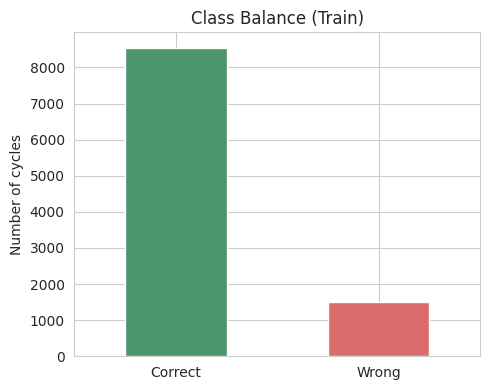

In [9]:
# Chart: class balance right where the label is created
fig, ax = plt.subplots(figsize=(5, 4))
train_df["Technique"].value_counts().plot(kind="bar", ax=ax, color=["#4C956C", "#D96C6C"])
ax.set_title("Class Balance (Train)")
ax.set_xlabel("")
ax.set_ylabel("Number of cycles")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("chart_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Feature / label separation (closing the circularity gap)

The 6 columns above were used to **build** the label. They are excluded from the columns used
to **predict** it. The model only sees the other 9 raw measurements, plus 3 new ratio features
built exclusively from those same 9 (never touching a label-source column), so there's no path
for the label-defining numbers to leak into the inputs, directly or by simple arithmetic.

In [10]:
non_label_features = [
    "Peak_Flow_L_s", "Min_Flow_L_s", "Mean_Flow_L_s", "Flow_Std_L_s",
    "Peak_Pressure_cmH2O", "Min_Pressure_cmH2O", "Mean_Pressure_cmH2O", "Pressure_Std_cmH2O",
    "Mean_Tidal_Volume_L",
]

def add_derived_features(data):
    data = data.copy()
    data["Flow_Pressure_Ratio"] = data["Peak_Flow_L_s"] / data["Peak_Pressure_cmH2O"].replace(0, np.nan)
    data["Mean_Flow_Pressure_Ratio"] = data["Mean_Flow_L_s"] / data["Mean_Pressure_cmH2O"].replace(0, np.nan)
    data["Volume_Flow_Ratio"] = data["Mean_Tidal_Volume_L"] / data["Mean_Flow_L_s"].replace(0, np.nan)
    return data

train_df = add_derived_features(train_df)
test_df = add_derived_features(test_df)

derived_features = ["Flow_Pressure_Ratio", "Mean_Flow_Pressure_Ratio", "Volume_Flow_Ratio"]
feature_columns = non_label_features + derived_features

X_train = train_df[feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0)
X_test = test_df[feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0)
y_train = train_df["Technique"].map({"Correct": 0, "Wrong": 1})
y_test = test_df["Technique"].map({"Correct": 0, "Wrong": 1})

print("Features used by the model:", feature_columns)
print("X_train:", X_train.shape, " X_test:", X_test.shape)

overlap_check = set(feature_columns) & set(label_features)
print("Overlap between model features and label-source columns:", overlap_check, "(must be empty)")


Features used by the model: ['Peak_Flow_L_s', 'Min_Flow_L_s', 'Mean_Flow_L_s', 'Flow_Std_L_s', 'Peak_Pressure_cmH2O', 'Min_Pressure_cmH2O', 'Mean_Pressure_cmH2O', 'Pressure_Std_cmH2O', 'Mean_Tidal_Volume_L', 'Flow_Pressure_Ratio', 'Mean_Flow_Pressure_Ratio', 'Volume_Flow_Ratio']
X_train: (10051, 12)  X_test: (3086, 12)
Overlap between model features and label-source columns: set() (must be empty)


## 5. Scaling (fit on train only)

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 6. Classical ML models

In [12]:
results = []

def score_row(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Wrong)": precision_score(y_true, y_pred, zero_division=0),
        "Recall (Wrong)": recall_score(y_true, y_pred, zero_division=0),
        "F1 (Wrong)": f1_score(y_true, y_pred, zero_division=0),
    }

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
pred_lr = log_reg.predict(X_test_scaled)

rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE)
rf.fit(X_train, y_train)  # tree models don't need scaling
pred_rf = rf.predict(X_test)

svm = SVC(kernel="rbf", class_weight="balanced", probability=True, random_state=RANDOM_STATE)
svm.fit(X_train_scaled, y_train)
pred_svm = svm.predict(X_test_scaled)

results.append(score_row("Logistic Regression", y_test, pred_lr))
results.append(score_row("Random Forest", y_test, pred_rf))
results.append(score_row("SVM (RBF)", y_test, pred_svm))

ml_results_df = pd.DataFrame(results)
ml_results_df


,Model,Accuracy,Precision (Wrong),Recall (Wrong),F1 (Wrong)
0,Logistic Regression,0.763124,0.274696,0.510050,0.357080
1,Random Forest,0.927414,0.899083,0.492462,0.636364
2,SVM (RBF),0.935191,0.700405,0.869347,0.775785


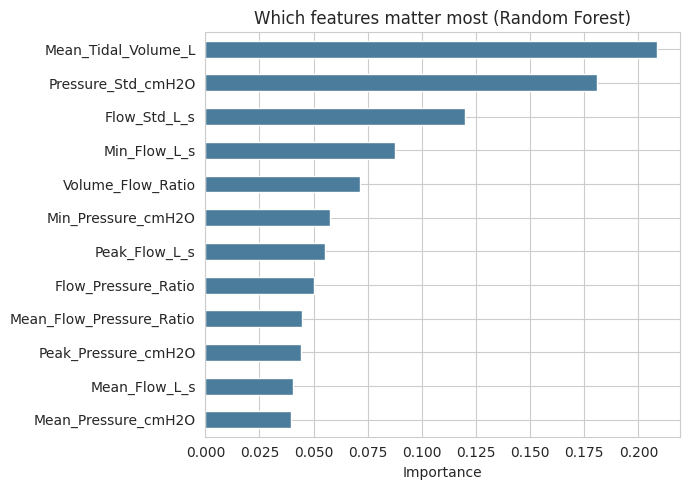

In [13]:
# Chart: which features the Random Forest actually relied on
importances = pd.Series(rf.feature_importances_, index=feature_columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
importances.plot(kind="barh", ax=ax, color="#4C7C9C")
ax.set_title("Which features matter most (Random Forest)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig("chart_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Deep learning model (MLP)

This is the "DL" half of the hybrid: a multi-layer perceptron (feed-forward neural network)
trained on the same tabular features. It's the right-sized deep learning model for this data —
the current dataset is cycle-level *summary statistics*, not raw waveforms, so a CNN/LSTM
wouldn't have the time-series signal it needs yet (see the note at the end of this notebook
about extending to raw audio/waveform data for that).

In [14]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    max_iter=500,
    random_state=RANDOM_STATE,
    early_stopping=True,
)
mlp.fit(X_train_scaled, y_train)
pred_mlp = mlp.predict(X_test_scaled)

results.append(score_row("MLP (Deep Learning)", y_test, pred_mlp))
all_results_df = pd.DataFrame(results)
all_results_df


,Model,Accuracy,Precision (Wrong),Recall (Wrong),F1 (Wrong)
0,Logistic Regression,0.763124,0.274696,0.510050,0.357080
1,Random Forest,0.927414,0.899083,0.492462,0.636364
2,SVM (RBF),0.935191,0.700405,0.869347,0.775785
3,MLP (Deep Learning),0.930979,0.890295,0.530151,0.664567


## 8. Compare all models + confusion matrix for the best one

In [15]:
best_row = all_results_df.loc[all_results_df["F1 (Wrong)"].idxmax()]
print("Best model by F1 (Wrong):", best_row["Model"])
print()
print(all_results_df.sort_values("F1 (Wrong)", ascending=False).to_string(index=False))

preds_by_name = {"Logistic Regression": pred_lr, "Random Forest": pred_rf, "SVM (RBF)": pred_svm, "MLP (Deep Learning)": pred_mlp}
best_pred = preds_by_name[best_row["Model"]]

cm = confusion_matrix(y_test, best_pred)
cm_df = pd.DataFrame(cm, index=["True: Correct", "True: Wrong"], columns=["Pred: Correct", "Pred: Wrong"])
cm_df


Best model by F1 (Wrong): SVM (RBF)

              Model  Accuracy  Precision (Wrong)  Recall (Wrong)  F1 (Wrong)
          SVM (RBF)  0.935191           0.700405        0.869347    0.775785
MLP (Deep Learning)  0.930979           0.890295        0.530151    0.664567
      Random Forest  0.927414           0.899083        0.492462    0.636364
Logistic Regression  0.763124           0.274696        0.510050    0.357080


,Pred: Correct,Pred: Wrong
True: Correct,2540,148
True: Wrong,52,346


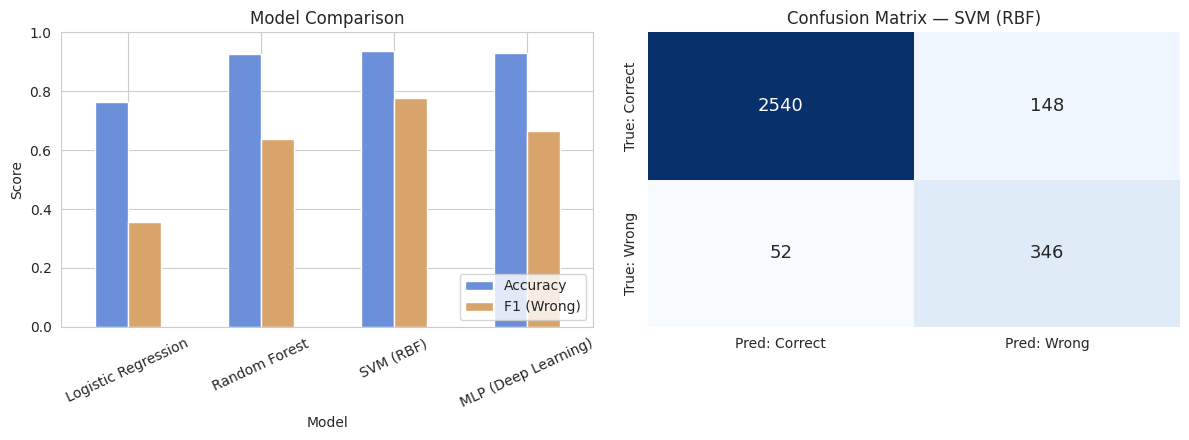

In [20]:
# Chart: model comparison + confusion matrix for the winner, right where we picked it
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

plot_df = all_results_df.set_index("Model")[["Accuracy", "F1 (Wrong)"]]
plot_df.plot(kind="bar", ax=axes[0], color=["#6C8FD9", "#D9A46C"])
axes[0].set_title("Model Comparison")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(loc="lower right")

sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", ax=axes[1], cbar=False, annot_kws={"size": 13})
axes[1].set_title(f"Confusion Matrix — {best_row['Model']}")

plt.tight_layout()
plt.savefig("chart_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


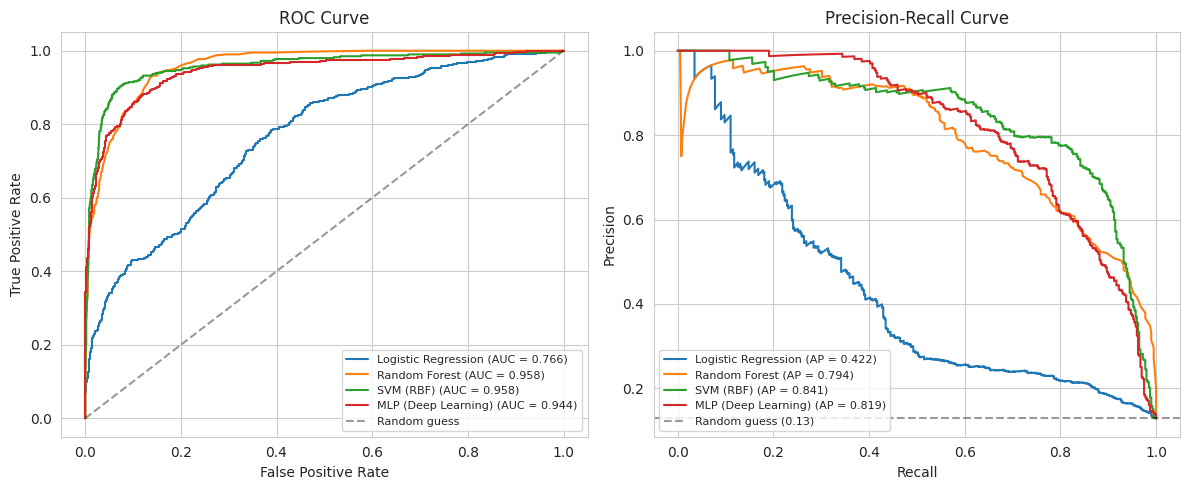

In [18]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

models_for_curves = {
    "Logistic Regression": (log_reg, X_test_scaled),
    "Random Forest": (rf, X_test),
    "SVM (RBF)": (svm, X_test_scaled),
    "MLP (Deep Learning)": (mlp, X_test_scaled),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, (model, X_eval) in models_for_curves.items():
    y_proba = model.predict_proba(X_eval)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    axes[1].plot(rec, prec, label=f"{name} (AP = {ap:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4, label="Random guess")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend(fontsize=8)

baseline = y_test.mean()
axes[1].axhline(baseline, ls="--", color="k", alpha=0.4, label=f"Random guess ({baseline:.2f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("chart_roc_pr.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Save the best model (for deployment)

Saves the trained model, the scaler, and the exact feature list/order together, so the same
preprocessing is guaranteed to be used at prediction time later (a common real-world bug is
retraining with one feature order and predicting with another).

In [17]:
best_model_lookup = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "SVM (RBF)": svm,
    "MLP (Deep Learning)": mlp,
}
best_model = best_model_lookup[best_row["Model"]]
needs_scaling = best_row["Model"] != "Random Forest"

bundle = {
    "model": best_model,
    "scaler": scaler,
    "feature_columns": feature_columns,
    "needs_scaling": needs_scaling,
    "model_name": best_row["Model"],
    "label_map": {0: "Correct", 1: "Wrong"},
}
joblib.dump(bundle, "smart_inhalo_model.pkl")
print(f"Saved '{best_row['Model']}' as smart_inhalo_model.pkl, ready for the app.")


Saved 'SVM (RBF)' as smart_inhalo_model.pkl, ready for the app.


## 9b. Try it yourself — predict a new breathing cycle

In [26]:
# Load the saved model bundle (self-contained - works even in a fresh session)
bundle = joblib.load("smart_inhalo_model.pkl")
model = bundle["model"]
scaler = bundle["scaler"]
feature_columns = bundle["feature_columns"]
needs_scaling = bundle["needs_scaling"]
label_map = bundle["label_map"]


def predict_technique(sample):
    """
    Takes a dict of the 9 raw breathing measurements and returns the
    predicted technique label using the trained model saved above.
    """
    row = dict(sample)
    row["Flow_Pressure_Ratio"] = row["Peak_Flow_L_s"] / row["Peak_Pressure_cmH2O"] if row["Peak_Pressure_cmH2O"] else 0
    row["Mean_Flow_Pressure_Ratio"] = row["Mean_Flow_L_s"] / row["Mean_Pressure_cmH2O"] if row["Mean_Pressure_cmH2O"] else 0
    row["Volume_Flow_Ratio"] = row["Mean_Tidal_Volume_L"] / row["Mean_Flow_L_s"] if row["Mean_Flow_L_s"] else 0

    X_row = pd.DataFrame([row])[feature_columns].replace([np.inf, -np.inf], np.nan).fillna(0)
    X_for_model = scaler.transform(X_row) if needs_scaling else X_row

    pred = model.predict(X_for_model)[0]
    label = label_map[pred]
    confidence = model.predict_proba(X_for_model)[0][pred] if hasattr(model, "predict_proba") else None

    print(f"Predicted technique: {label}")
    if confidence is not None:
        print(f"Model confidence: {confidence:.1%}")
    return label, confidence


# Edit these 9 values to test a different breathing cycle
new_cycle = {
    "Peak_Flow_L_s": 1.12, "Min_Flow_L_s": -0.72, "Mean_Flow_L_s": 1.18, "Flow_Std_L_s": 0.60,
    "Peak_Pressure_cmH2O": 5.62, "Min_Pressure_cmH2O": 0.60, "Mean_Pressure_cmH2O": 2.93,
    "Pressure_Std_cmH2O": 1.32, "Mean_Tidal_Volume_L": 1.01,
}
predict_technique(new_cycle)

Predicted technique: Wrong
Model confidence: 60.2%


('Wrong', np.float64(0.6019825115927969))

## 10. Leakage safeguards used in this notebook (recap)

- Train/test split by **subject**, done before any labeling or scaling.
- Label thresholds computed from **train subjects only**, then applied to test.
- The 6 columns used to build the label are **excluded** from the model's input features.
- Derived ratio features are built only from non-label columns, so they can't reintroduce the
  label-source information indirectly.
- Scaler fit on train only, applied to test without refitting.
- Reported metrics (Precision/Recall/F1) are for the `Wrong` class specifically, since it's the
  minority class and the one that actually matters for this problem.

## 11. Where to go next: real inhaler audio data

This notebook uses real respiratory *signals*, but not real *inhaler-use* events — the
`Correct`/`Wrong` label is a technical proxy, as noted above. Published research shows inhaler
technique can be classified directly from **audio** (a microphone recording of the inhaler in
use), with real public datasets available:

- **ICBHI 2017** respiratory sound database — official download (no login required):
  `https://bhichallenge.med.auth.gr/sites/default/files/ICBHI_final_database/ICBHI_final_database.zip`
- **RDA (Respiratory and Drug Actuation) dataset** — real inhaler-use audio, code at
  `https://github.com/snousias/Revisiting-Content-Based-Audio-Classification-for-Asthma-Medication-Adherence`

These aren't downloaded in this notebook (large audio files, and not reachable from every
sandboxed environment) — but if you pull one of them locally, the same leak-safe pattern used
above applies: build features from the audio, keep any label-defining columns out of the
model's inputs, split by subject, and only then train. That audio data would also unlock a
genuine 1D-CNN/LSTM branch, since it's raw waveform rather than pre-aggregated statistics.